# Arabidopsis Root Atlas — Method Comparison

Shahan et al.\ 2022 (*Dev. Cell*; DTNE's `rc.integrated.data.h5ad`), n = 110,427.

**Main result is geometry: DEMaP + trustworthiness.** Reported as a pair because they encode the global/local tradeoff — kmeans landmarks favour local structure (high trust, branches resolved), fps favours global (high DEMaP, flatter). We use kmeans and report both, so the choice is visible in the table.

Baselines use DTNE's published per-dataset settings (t-SNE perplexity 50, UMAP defaults, PHATE knn 100, DTNE k=800/l1=5). HeatGeo omitted (infeasible at 110k). EntroPath fixed at `alpha_decay | k=15 | kmeans` — the joint DEMaP/trustworthiness winner, on the flat part of the k curve. **Pseudotime is in the appendix** (ordering is diffusion-power-sensitive; see note there).

## Imports

In [1]:
import sys
import pickle
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import scanpy as sc
from scipy.stats import spearmanr

# Method classes — adjust import paths to your codebase
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import phate
from entropath import EntroPath      # ~/.../src/entropath
from dtne import DTNE                # adjust to your DTNE import

from utils.bio_utils import (
    run_methods, plot_embedding_row, plot_embedding_grid,
    plot_pseudotime_panels, plot_pseudotime_boxplot,
    save_bio_artifacts, save_metrics_csv, correlation_triple, geodesic_from_root, BIO_PLOT_ORDER,
)

import warnings; warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

## Configuration

In [14]:
SEED        = 42

# EntroPath — fixed recipe (joint DEMaP/trust winner; flat k curve)
EP_KERNEL, EP_K, EP_LM = "alpha_decay", 15, "kmeans"

# Baselines — DTNE's published settings for this dataset
TSNE_PERPLEXITY = 50
DTNE_K, DTNE_L1 = 800, 5
PHATE_KNN       = 100

# Geometry metric protocol (subsampled; DEMaP + trustworthiness share the draws)
EVAL_N, EVAL_REPEATS, GEO_K, TRUST_K = 2000, 50, 50, 15 # GEO_K is DEMAP_K

RESULTS_DIR = PROJECT_ROOT / "results" / "root_atlas"
FIGURES_DIR = PROJECT_ROOT / "figures" / "root_atlas"
DATA_DIR    = PROJECT_ROOT / "data" / "root_atlas"
for d in (RESULTS_DIR, FIGURES_DIR, DATA_DIR): d.mkdir(parents=True, exist_ok=True)

print(f"EntroPath: {EP_KERNEL} | k={EP_K} | {EP_LM}   DTNE k={DTNE_K}/l1={DTNE_L1}   PHATE knn={PHATE_KNN}")

EntroPath: alpha_decay | k=15 | kmeans   DTNE k=800/l1=5   PHATE knn=100


## Load

`X_pca` is the input for every method. No reindexing — the positional root from `uns['iroot']` stays valid. `consensus_time` is already in `adata.uns` (== DTNE's CSV, stored root-low).

In [3]:
CACHE_PATH = DATA_DIR / "rc.integrated.data.h5ad"
if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Place rc.integrated.data.h5ad in {DATA_DIR}. DTNE Google Drive: "
        "https://drive.google.com/drive/folders/1UFKBWFJ7BhzcABpa4DZXssthQuTGMfmU")

adata = sc.read_h5ad(CACHE_PATH)
X = np.asarray(adata.obsm["X_pca"])
print(f"{adata.shape}  X_pca {X.shape}")

adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
labels      = adata.obs["cell_type"].values
label_codes = adata.obs["cell_type"].cat.codes.values
categories  = list(adata.obs["cell_type"].cat.categories)

cmap = plt.get_cmap("tab20")
zip_types   = {c: matplotlib.colors.to_hex(cmap(i % 20)) for i, c in enumerate(categories)}
cell_colors = [zip_types[l] for l in labels]

ROOT_CELL_IDX  = int(np.ravel(adata.uns["iroot"])[0]) if "iroot" in adata.uns else 3631
consensus_time = np.asarray(adata.uns["consensus_time"], dtype=float).reshape(-1)
assert consensus_time.shape[0] == adata.n_obs
print(f"root={ROOT_CELL_IDX} ({labels[ROOT_CELL_IDX]})   cell types={len(categories)}")

(110427, 17513)  X_pca (110427, 50)
root=3631 (Endodermis)   cell types=14


## Run methods

Defined inline (this dataset needs DTNE's per-dataset baseline settings). **Heavy cell** — t-SNE and DTNE(k=800) dominate; run once and let `save_bio_artifacts` cache the embeddings.

In [4]:
methods = {
    "PCA":       PCA(n_components=2),
    "t-SNE":     TSNE(perplexity=50, random_state=SEED),
    "UMAP":      UMAP(random_state=SEED),
    "PHATE":     phate.PHATE(knn=100, random_state=SEED, verbose=False),
    "DTNE":      DTNE(k_neighbors=800, l1=5),
    "EntroPath": EntroPath(k_neighbors=20, random_state=SEED, kernel="alpha_decay",
                           mds_solver="smacof", landmarks_method="kmeans", verbose=False),
}

print(f"Methods: {list(methods.keys())}\n")
cache = RESULTS_DIR / "root_atlas_embeddings.pkl"
if cache.exists():
    d = pickle.load(open(cache, "rb"))
    embeddings, runtimes = d["embeddings"], d["runtimes"]
    print("loaded from cache")
else:
    embeddings, runtimes = run_methods(methods, X)
    pickle.dump({"embeddings": embeddings, "runtimes": runtimes}, open(cache, "wb"))

PLOT_ORDER = [m for m in BIO_PLOT_ORDER if m in embeddings]

Methods: ['PCA', 't-SNE', 'UMAP', 'PHATE', 'DTNE', 'EntroPath']

  PCA                done (   0.1s)
  t-SNE              done ( 313.2s)
  UMAP               

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


done ( 124.5s)
  PHATE                  SGD-MDS may not have converged: stress changed by 2.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
done (  56.9s)
  DTNE               done (23615.8s)
  EntroPath          done (  14.5s)  (t_power = 43)

=== Done — 6/6 methods succeeded ===


In [10]:
#save
#import pickle
#with open(RESULTS_DIR / "root_atlas_embeddings.pkl", "wb") as f:
#    pickle.dump({"embeddings": embeddings, "runtimes": runtimes}, f)
#print("saved", list(embeddings.keys()))

saved ['PCA', 't-SNE', 'UMAP', 'PHATE', 'DTNE', 'EntroPath']


In [21]:
# run only EntroPath
#methods2 = {"EntroPath": EntroPath(k_neighbors=15, random_state=SEED, kernel="alpha_decay",
#                                   mds_solver="smacof", landmarks_method="kmeans", verbose=False)}
#emb2, runtimes2 = run_methods(methods2, X)
#embeddings["EntroPath"] = emb2["EntroPath"]
#runtimes["EntroPath"]   = runtimes2["EntroPath"]   # the real float, not None

In [ ]:
#load
#d = pickle.load(open(RESULTS_DIR / "root_atlas_embeddings.pkl", "rb"))
#assert d["embeddings"]["DTNE"].shape[0] == adata.n_obs
#print("DTNE recovered:", d["embeddings"]["DTNE"].shape, "runtime:", d["runtimes"]["DTNE"])

## Embeddings (coloured by cell type)

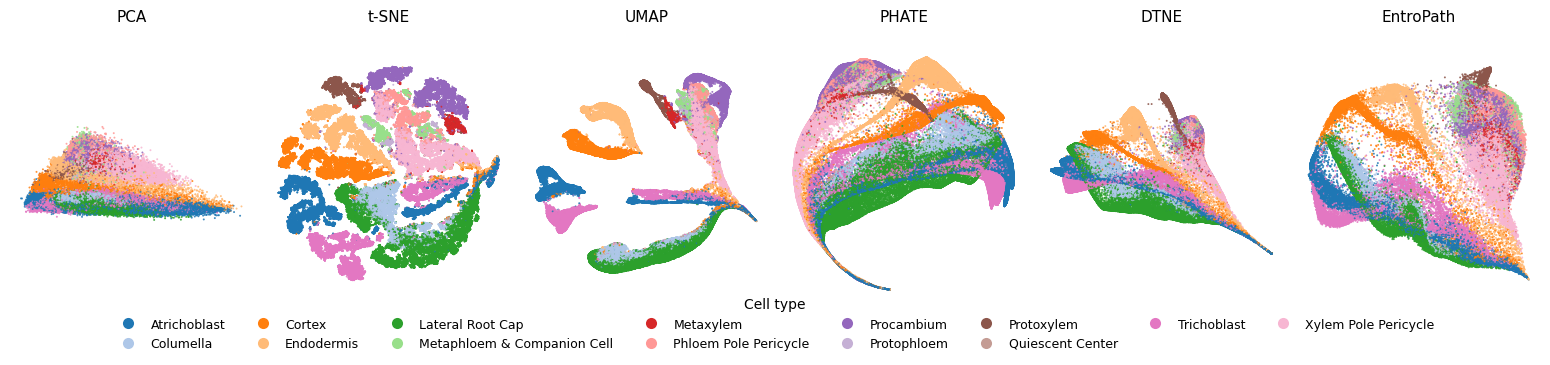

(<Figure size 1560x360 with 6 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>], dtype=object))

In [11]:
plot_embedding_row(embeddings, PLOT_ORDER, cell_colors, zip_types,
                   runtimes=None, save_path=FIGURES_DIR / "root_atlas_row")

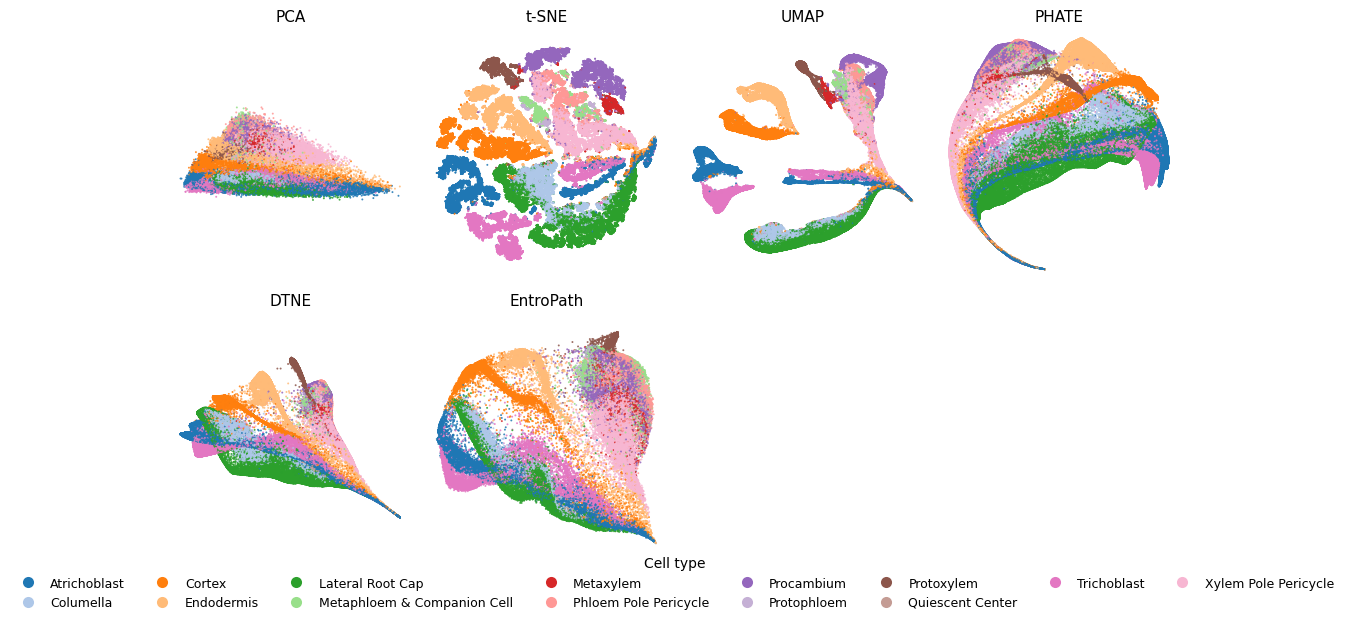

(<Figure size 1040x620 with 8 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>, <Axes: >, <Axes: >],
       dtype=object))

In [12]:
plot_embedding_grid(embeddings, PLOT_ORDER, cell_colors, zip_types,
                    runtimes=None, save_path=FIGURES_DIR / "root_atlas_grid")

## Geometry metrics — DEMaP + trustworthiness

The main quantitative result. Both on the same fixed-seed subsamples: **DEMaP** (Spearman of high-D geodesic vs embedding distance — global) and **trustworthiness** (local-neighbour preservation). Reported with std over `EVAL_REPEATS` draws for t-SNE, UMAP, PHATE, DTNE, EntroPath (PCA / HeatGeo excluded). To recover DTNE's absolute DEMaP, swap this body for their exact DEMaP function (`GEO_K` is the parameter that shifts it).

In [15]:
from sklearn.neighbors import kneighbors_graph
from sklearn.manifold import trustworthiness
from scipy.sparse.csgraph import shortest_path
from scipy.spatial.distance import pdist
from utils.bio_utils import continuity

metric_methods = [m for m in ["t-SNE","UMAP","PHATE","DTNE","EntroPath"] if m in embeddings]
rng = np.random.default_rng(SEED)
iu  = np.triu_indices(EVAL_N, k=1)
demap = {m: [] for m in metric_methods}
trust = {m: [] for m in metric_methods}
cont  = {m: [] for m in metric_methods}

for _ in range(EVAL_REPEATS):
    sub = np.sort(rng.choice(X.shape[0], size=EVAL_N, replace=False))
    Xs  = X[sub]
    geo = shortest_path(kneighbors_graph(Xs, n_neighbors=GEO_K, mode="distance"),
                        method="D", directed=False)[iu]
    fin = np.isfinite(geo)
    for m in metric_methods:
        Ys = np.asarray(embeddings[m])[sub]
        demap[m].append(spearmanr(geo[fin], pdist(Ys)[fin]).correlation)
        trust[m].append(trustworthiness(Xs, Ys, n_neighbors=TRUST_K))
        cont[m].append(continuity(Xs, Ys, n_neighbors=TRUST_K))

df_geom = pd.DataFrame({
    "DEMaP":      {m: np.mean(demap[m]) for m in metric_methods},
    "DEMaP_std":  {m: np.std(demap[m])  for m in metric_methods},
    "Trust":      {m: np.mean(trust[m]) for m in metric_methods},
    "Trust_std":  {m: np.std(trust[m])  for m in metric_methods},
    "Continuity":     {m: np.mean(cont[m]) for m in metric_methods},
    "Continuity_std": {m: np.std(cont[m])  for m in metric_methods},
})
print(f"Geometry metrics (n={EVAL_N}, repeats={EVAL_REPEATS}, geo_k={GEO_K}, trust_k={TRUST_K}):")
print(df_geom.round(3).to_string())
df_geom.to_csv(RESULTS_DIR / "root_atlas_geometry.csv")
print("\n=== LaTeX (paper table) ===")
print(df_geom[["DEMaP","Trust"]].round(3).to_latex(float_format="%.3f"))

Geometry metrics (n=2000, repeats=50, geo_k=50, trust_k=15):
           DEMaP  DEMaP_std  Trust  Trust_std  Continuity  Continuity_std
t-SNE      0.716      0.009  0.992      0.001       0.986           0.001
UMAP       0.690      0.013  0.994      0.000       0.991           0.001
PHATE      0.886      0.007  0.968      0.001       0.990           0.000
DTNE       0.850      0.009  0.978      0.001       0.994           0.000
EntroPath  0.843      0.008  0.980      0.001       0.993           0.000

=== LaTeX (paper table) ===
\begin{tabular}{lrr}
\toprule
 & DEMaP & Trust \\
\midrule
t-SNE & 0.716 & 0.992 \\
UMAP & 0.690 & 0.994 \\
PHATE & 0.886 & 0.968 \\
DTNE & 0.850 & 0.978 \\
EntroPath & 0.843 & 0.980 \\
\bottomrule
\end{tabular}



## Save artifacts

In [16]:
artifact_path = save_bio_artifacts(
    embeddings, runtimes, labels, label_codes, zip_types, X_shape=X.shape,
    config={"seed": SEED, "entropath": f"{EP_KERNEL}|k{EP_K}|{EP_LM}",
            "dtne_k": DTNE_K, "dtne_l1": DTNE_L1, "phate_knn": PHATE_KNN,
            "root_cell": ROOT_CELL_IDX, "dataset": "root_atlas", "n_obs": int(adata.n_obs)},
    results_dir=RESULTS_DIR, basename="root_atlas")
save_metrics_csv(df_geom, RESULTS_DIR, "root_atlas_geometry")
print(f"Saved to {artifact_path.relative_to(PROJECT_ROOT)}")

Saved to results/root_atlas/root_atlas_embeddings.pkl


---
# Appendix — Pseudotime

Reported honestly, **not** as a headline. EntroPath's root-anchored pseudotime reaches Spearman ≈ 0.65 against `consensus_time` at the embedding-selected diffusion power. Diagnostics showed the gap to DTNE (≈0.81) is in the *ordering* step, not the representation: a geodesic on `X_pca` reaches ≈0.83 on the same data, and EntroPath's diffusion ordering peaks at a *lower* diffusion power than the embedding-optimal one. A power-selection rule decoupled from the embedding — validated across datasets, not tuned against ground truth — is left as future work. Numbers below are at the fitted power; we did not tune power against `consensus_time`.

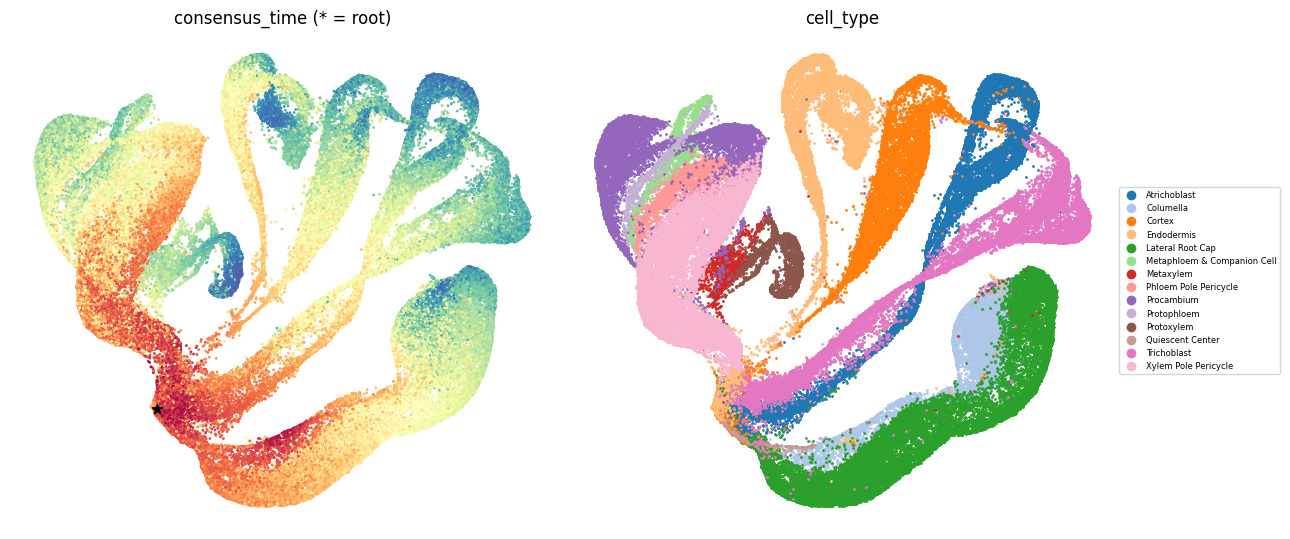

In [17]:
# Reference: canonical UMAP coloured by consensus_time (ground truth) and cell type
umap_ref = np.asarray(adata.obsm["umap"])
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].scatter(umap_ref[:,0], umap_ref[:,1], c=consensus_time, s=1, cmap="Spectral")
ax[0].scatter(*umap_ref[ROOT_CELL_IDX], s=60, c="k", marker="*")
ax[0].set_title("consensus_time (* = root)"); ax[0].axis("off")
for cat in categories:
    m = labels == cat
    ax[1].scatter(umap_ref[m,0], umap_ref[m,1], s=1, color=zip_types[cat], label=str(cat))
ax[1].set_title("cell_type"); ax[1].axis("off")
ax[1].legend(markerscale=6, fontsize=6, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "root_atlas_umap_reference.png", dpi=150, bbox_inches="tight")
plt.show()

Root cell 3631: type = Endodermis


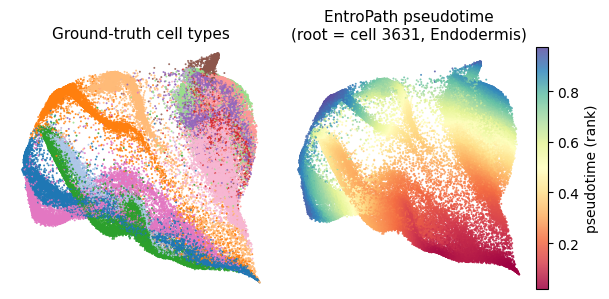

Root cell 3631: type = Endodermis


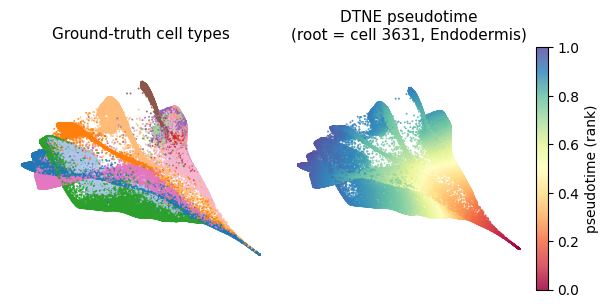

In [18]:
# Pseudotime panels (visualization)
if "EntroPath" in embeddings:
    pt_ep = plot_pseudotime_panels(
        methods["EntroPath"], "EntroPath", embeddings["EntroPath"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types, save_path=FIGURES_DIR / "root_atlas_entropath_pseudotime")
    if pt_ep is not None: adata.obs["pseudotime_entropath"] = pt_ep
if "DTNE" in embeddings:
    pt_dt = plot_pseudotime_panels(
        methods["DTNE"], "DTNE", embeddings["DTNE"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types, order_method="order_cells",
        save_path=FIGURES_DIR / "root_atlas_dtne_pseudotime")
    if pt_dt is not None: adata.obs["pseudotime_dtne"] = pt_dt

In [19]:
# Pseudotime vs consensus_time (raw; stored root-low, so a correct ordering is positive)
rows = []
for name, key in [("EntroPath","pseudotime_entropath"), ("DTNE","pseudotime_dtne")]:
    if key not in adata.obs: continue
    pt = adata.obs[key].values
    m = ~(np.isnan(pt) | np.isnan(consensus_time))
    p, s, k = correlation_triple(consensus_time[m], pt[m])
    rows.append({"Method": name, "Pearson": p, "Spearman": s, "Kendall": k})
df_pt = pd.DataFrame(rows).set_index("Method")
print("Pseudotime vs consensus_time (DTNE published: Pearson 0.798, Spearman 0.811):")
print(df_pt.round(3).to_string())
save_metrics_csv(df_pt, RESULTS_DIR, "root_atlas_pseudotime_consensus")

Pseudotime vs consensus_time (DTNE published: Pearson 0.798, Spearman 0.811):
           Pearson  Spearman  Kendall
Method                               
EntroPath    0.745     0.740    0.545
DTNE         0.798     0.811    0.613


PosixPath('/Users/przemyslawrola/Desktop/EntroPath/results/root_atlas/root_atlas_pseudotime_consensus_metrics.csv')

In [20]:
# Pseudotime vs root geodesic (cross-dataset-consistent protocol used on datasets
# lacking a consensus ordering; weaker self-referential proxy than consensus_time above)
geo = geodesic_from_root(X, ROOT_CELL_IDX, k_neighbors=GEO_K)
reachable = np.isfinite(geo)
if (~reachable).any():
    print(f"{(~reachable).sum()} cells unreachable from root; correlating on reachable only.")
rows = []
for name, key in [("EntroPath","pseudotime_entropath"), ("DTNE","pseudotime_dtne")]:
    if key not in adata.obs: continue
    pt = adata.obs[key].values
    m = reachable & ~np.isnan(pt)
    p, s, k = correlation_triple(geo[m], pt[m])
    rows.append({"Method": name, "Pearson": p, "Spearman": s, "Kendall": k})
df_pt_geo = pd.DataFrame(rows).set_index("Method")
print("Pseudotime vs root geodesic (X_pca):")
print(df_pt_geo.round(3).to_string())
save_metrics_csv(df_pt_geo, RESULTS_DIR, "root_atlas_pseudotime_geodesic")

Pseudotime vs root geodesic (X_pca):
           Pearson  Spearman  Kendall
Method                               
EntroPath    0.833     0.876    0.697
DTNE         0.969     0.932    0.788


PosixPath('/Users/przemyslawrola/Desktop/EntroPath/results/root_atlas/root_atlas_pseudotime_geodesic_metrics.csv')